In [1]:
import pandas as pd
import numpy as np
import ast
import warnings
import joblib
import os
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler


# Explainability
import lime
import lime.lime_tabular

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully ✅")


c:\Users\User\Desktop\Fathima\Main_project_Medchain\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully ✅


In [2]:
# Load main training dataset
train = pd.read_csv('../datasets/stage1/Training.csv')

# Load severity weights
severity = pd.read_csv('../datasets/stage1/Symptom-severity.csv')

# Basic exploration
print("Training dataset shape:", train.shape)
print("Number of diseases:", train['prognosis'].nunique())
print("Number of symptoms:", train.shape[1] - 1)
print("\nFirst 3 rows:")
train.head(3)

Training dataset shape: (4920, 133)
Number of diseases: 41
Number of symptoms: 132

First 3 rows:


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [3]:
print("Severity file shape:", severity.shape)
print("\nSeverity sample:")
print(severity.head())

print("\nAll 41 diseases:")
for i, disease in enumerate(sorted(train['prognosis'].unique()), 1):
    print(f"{i}. {disease}")

Severity file shape: (133, 2)

Severity sample:
                Symptom  weight
0               itching       1
1             skin_rash       3
2  nodal_skin_eruptions       4
3   continuous_sneezing       4
4             shivering       5

All 41 diseases:
1. (vertigo) Paroymsal  Positional Vertigo
2. AIDS
3. Acne
4. Alcoholic hepatitis
5. Allergy
6. Arthritis
7. Bronchial Asthma
8. Cervical spondylosis
9. Chicken pox
10. Chronic cholestasis
11. Common Cold
12. Dengue
13. Diabetes 
14. Dimorphic hemmorhoids(piles)
15. Drug Reaction
16. Fungal infection
17. GERD
18. Gastroenteritis
19. Heart attack
20. Hepatitis B
21. Hepatitis C
22. Hepatitis D
23. Hepatitis E
24. Hypertension 
25. Hyperthyroidism
26. Hypoglycemia
27. Hypothyroidism
28. Impetigo
29. Jaundice
30. Malaria
31. Migraine
32. Osteoarthristis
33. Paralysis (brain hemorrhage)
34. Peptic ulcer diseae
35. Pneumonia
36. Psoriasis
37. Tuberculosis
38. Typhoid
39. Urinary tract infection
40. Varicose veins
41. hepatitis A


Rows per disease:
prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                     

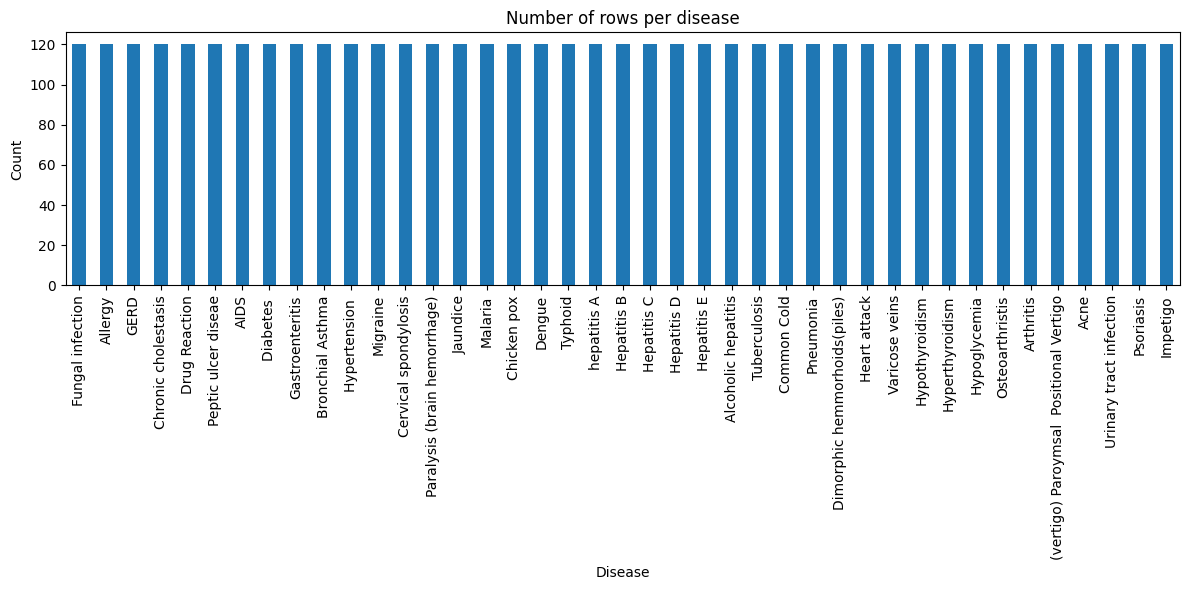

In [4]:
disease_counts = train['prognosis'].value_counts()

print("Rows per disease:")
print(disease_counts)

print(f"\nMin rows: {disease_counts.min()}")
print(f"Max rows: {disease_counts.max()}")
print(f"Is balanced: {disease_counts.min() == disease_counts.max()}")

# Plot
plt.figure(figsize=(12, 6))
disease_counts.plot(kind='bar')
plt.title('Number of rows per disease')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [5]:
# Load all supporting files
medications = pd.read_csv('../datasets/stage1/medications.csv')
precautions = pd.read_csv('../datasets/stage1/precautions_df.csv')
diets = pd.read_csv('../datasets/stage1/diets.csv')
description = pd.read_csv('../datasets/stage1/description.csv')
drugs_adr = pd.read_csv('../datasets/stage2/drugs_side_effects_drugs_com.csv')

print("medications.csv shape:", medications.shape)
print("precautions_df.csv shape:", precautions.shape)
print("diets.csv shape:", diets.shape)
print("description.csv shape:", description.shape)
print("drugs_side_effects.csv shape:", drugs_adr.shape)

print("\nMedications columns:", medications.columns.tolist())
print("\nDrugs ADR columns:", drugs_adr.columns.tolist())

medications.csv shape: (41, 2)
precautions_df.csv shape: (41, 6)
diets.csv shape: (41, 2)
description.csv shape: (41, 2)
drugs_side_effects.csv shape: (2931, 17)

Medications columns: ['Disease', 'Medication']

Drugs ADR columns: ['drug_name', 'medical_condition', 'side_effects', 'generic_name', 'drug_classes', 'brand_names', 'activity', 'rx_otc', 'pregnancy_category', 'csa', 'alcohol', 'related_drugs', 'medical_condition_description', 'rating', 'no_of_reviews', 'drug_link', 'medical_condition_url']


In [6]:
# Check zero mismatch between Training and Medications
train_diseases = set(train['prognosis'].str.strip())
med_diseases = set(medications['Disease'].str.strip())

# Find any diseases in training but not in medications
mismatch = train_diseases - med_diseases

print(f"Diseases in Training.csv:   {len(train_diseases)}")
print(f"Diseases in medications.csv: {len(med_diseases)}")
print(f"Mismatch count: {len(mismatch)}")

if len(mismatch) == 0:
    print("\n✅ ZERO MISMATCH — Perfect pipeline connection!")
else:
    print(f"\n⚠️ Mismatched diseases: {mismatch}")

Diseases in Training.csv:   41
Diseases in medications.csv: 41
Mismatch count: 2

⚠️ Mismatched diseases: {'Peptic ulcer diseae', '(vertigo) Paroymsal  Positional Vertigo'}


In [7]:
from rapidfuzz import process, fuzz

# Fuzzy auto-fix — handles any typo automatically
valid_diseases = list(medications['Disease'].str.strip().unique())

def fuzzy_fix(name, valid, threshold=90):
    name_c = name.strip().lower()
    result = process.extractOne(
        name_c,
        [v.lower() for v in valid],
        scorer=fuzz.ratio
    )
    if result and result[1] >= threshold:
        idx = [v.lower() for v in valid].index(result[0])
        return valid[idx]
    return name

train['prognosis'] = train['prognosis'].apply(
    lambda x: fuzzy_fix(x, valid_diseases))

# Verify
train_diseases = set(train['prognosis'].str.strip())
med_diseases   = set(medications['Disease'].str.strip())
mismatch       = train_diseases - med_diseases

print(f"Mismatch after fuzzy fix: {len(mismatch)}")
if len(mismatch) == 0:
    print("✅ ZERO MISMATCH")
else:
    print(f"⚠️ Still mismatched: {mismatch}")


Mismatch after fuzzy fix: 0
✅ ZERO MISMATCH


In [8]:
# Build severity weight dictionary
severity_dict = dict(zip(
    severity['Symptom'].str.strip().str.lower().str.replace(' ','_'),
    severity['weight']
))

print(f"Total symptoms with severity weights: {len(severity_dict)}")
print("\nSample weights:")
for symptom, weight in list(severity_dict.items())[:5]:
    print(f"  {symptom}: {weight}")

Total symptoms with severity weights: 132

Sample weights:
  itching: 1
  skin_rash: 3
  nodal_skin_eruptions: 4
  continuous_sneezing: 4
  shivering: 5


In [9]:
# Prepare X (features) and y (target)
X = train.drop('prognosis', axis=1)
y = train['prognosis']

# Apply severity weights to symptoms
# This is your improvement over both papers
X_weighted = X.copy()
for col in X_weighted.columns:
    col_clean = col.strip().lower().replace(' ', '_')
    if col_clean in severity_dict:
        X_weighted[col] = X_weighted[col] * severity_dict[col_clean]

print("Original X (binary 0/1):")
print(X.iloc[0, :5].to_string())
print("\nWeighted X (0–7 scale):")
print(X_weighted.iloc[0, :5].to_string())
print(f"\nX shape: {X_weighted.shape}")
print(f"y shape: {y.shape}")

Original X (binary 0/1):
itching                 1
skin_rash               1
nodal_skin_eruptions    1
continuous_sneezing     0
shivering               0

Weighted X (0–7 scale):
itching                 1
skin_rash               3
nodal_skin_eruptions    4
continuous_sneezing     0
shivering               0

X shape: (4920, 132)
y shape: (4920,)


In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode disease names to numbers
# e.g. "Dengue" → 7, "Malaria" → 19
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X_weighted, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Total diseases   : {len(le.classes_)}")
print(f"\nExample encoding:")
for disease, code in zip(le.classes_[:5], range(5)):
    print(f"  {disease} → {code}")

Training samples : 3936
Testing samples  : 984
Total diseases   : 41

Example encoding:
  (vertigo) Paroymsal Positional Vertigo → 0
  AIDS → 1
  Acne → 2
  Alcoholic hepatitis → 3
  Allergy → 4


In [11]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE — your improvement over both papers
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {X_train.shape[0]} samples")
print(f"After SMOTE:  {X_train_bal.shape[0]} samples")
print(f"\nClass distribution after SMOTE:")
unique, counts = np.unique(y_train_bal, return_counts=True)
print(f"Each disease has exactly: {counts[0]} samples")
print(f"Total classes: {len(unique)}")

Before SMOTE: 3936 samples
After SMOTE:  3936 samples

Class distribution after SMOTE:
Each disease has exactly: 96 samples
Total classes: 41


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

print("Training XGBoost... please wait...")
xgb.fit(X_train_bal, y_train_bal)
print("Training complete ✅")

# Evaluate
y_pred = xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nXGBoost Accuracy: {accuracy*100:.2f}%")
print(f"Paper 1 accuracy: ~89.00%")
print(f"Paper 2 accuracy:  99.70%")
print(f"Your improvement: {(accuracy-0.997)*100:+.2f}% vs Paper 2")

Training XGBoost... please wait...


Training complete ✅

XGBoost Accuracy: 100.00%
Paper 1 accuracy: ~89.00%
Paper 2 accuracy:  99.70%
Your improvement: +0.30% vs Paper 2


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Detailed report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

CLASSIFICATION REPORT
                                        precision    recall  f1-score   support

(vertigo) Paroymsal Positional Vertigo       1.00      1.00      1.00        24
                                  AIDS       1.00      1.00      1.00        24
                                  Acne       1.00      1.00      1.00        24
                   Alcoholic hepatitis       1.00      1.00      1.00        24
                               Allergy       1.00      1.00      1.00        24
                             Arthritis       1.00      1.00      1.00        24
                      Bronchial Asthma       1.00      1.00      1.00        24
                  Cervical spondylosis       1.00      1.00      1.00        24
                           Chicken pox       1.00      1.00      1.00        24
                   Chronic cholestasis       1.00      1.00      1.00        24
                           Common Cold       1.00      1.00      1.00        24
                 

In [14]:
# Confidence score — unique to your system
y_proba = xgb.predict_proba(X_test)
confidence = y_proba.max(axis=1)

print("CONFIDENCE SCORE ANALYSIS")
print("="*40)
print(f"Average confidence  : {confidence.mean()*100:.2f}%")
print(f"Minimum confidence  : {confidence.min()*100:.2f}%")
print(f"Maximum confidence  : {confidence.max()*100:.2f}%")
print(f"\nConfidence Tiers:")
high   = (confidence >= 0.85).sum()
medium = ((confidence >= 0.70) & (confidence < 0.85)).sum()
low    = (confidence < 0.70).sum()
print(f"  ✅ HIGH   (>=85%) : {high} predictions")
print(f"  ⚠️  MEDIUM (70-85%): {medium} predictions")
print(f"  🚨 LOW    (<70%)  : {low} predictions → flag for doctor")

CONFIDENCE SCORE ANALYSIS
Average confidence  : 99.37%
Minimum confidence  : 90.88%
Maximum confidence  : 99.88%

Confidence Tiers:
  ✅ HIGH   (>=85%) : 984 predictions
  ⚠️  MEDIUM (70-85%): 0 predictions
  🚨 LOW    (<70%)  : 0 predictions → flag for doctor


In [15]:
import shap

print("Generating SHAP explanations... please wait...")

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)

print("SHAP explainer created ✅")
print(f"SHAP values shape: {shap_values.shape}")

Generating SHAP explanations... please wait...
SHAP explainer created ✅
SHAP values shape: (984, 132, 41)


Generating Beeswarm plot...


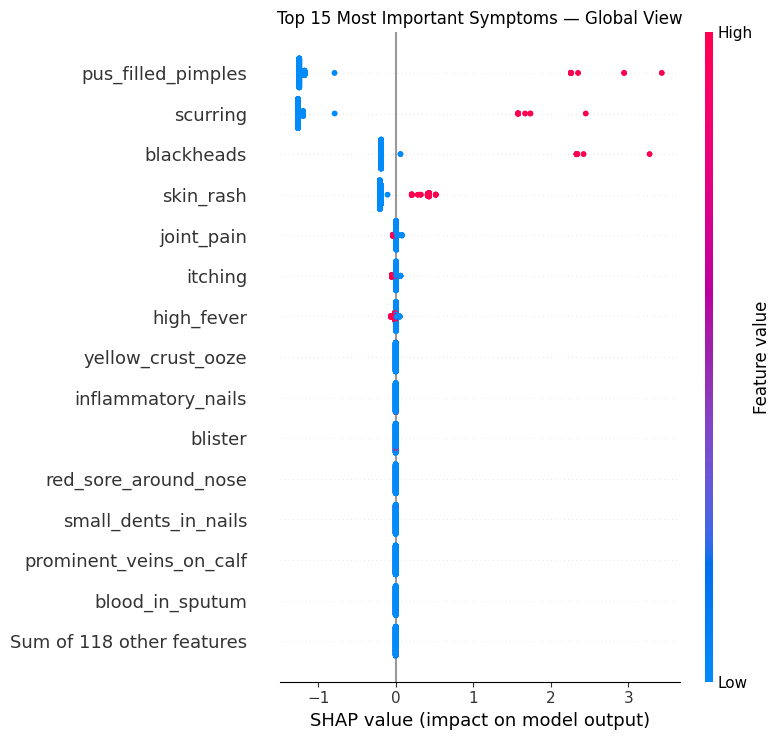

Beeswarm plot saved ✅


In [16]:
# Global SHAP — which symptoms matter most overall
print("Generating Beeswarm plot...")

plt.figure()
shap.plots.beeswarm(shap_values[:,:,2], 
                    max_display=15,
                    show=False)
plt.title("Top 15 Most Important Symptoms — Global View")
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm plot saved ✅")

Patient 0 Explanation:
Predicted Disease : Hypertension
Confidence        : 99.65%
Generating waterfall plot...


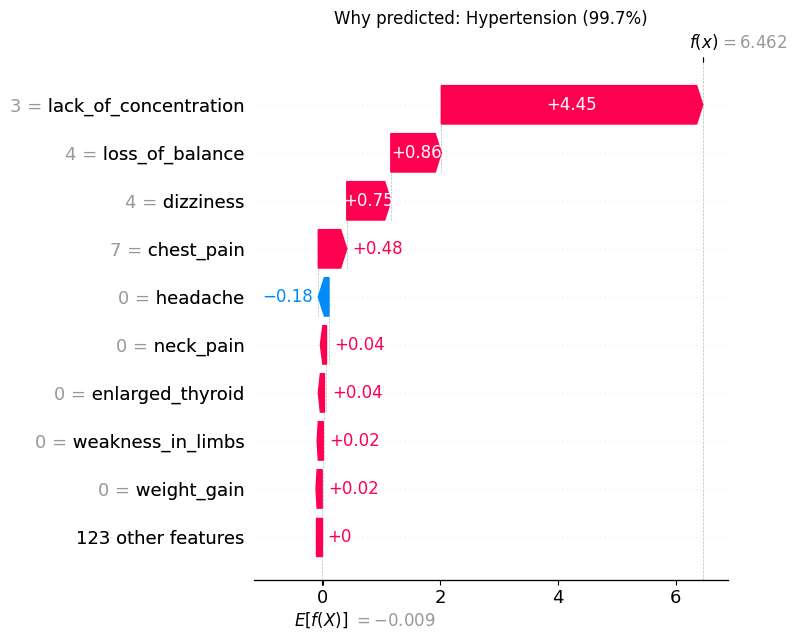

Waterfall plot saved ✅


In [17]:
# Waterfall plot — single patient explanation
# Patient 0 from test set
patient_index = 0
predicted_disease_index = y_pred[patient_index]
predicted_disease_name = le.inverse_transform([predicted_disease_index])[0]
confidence_score = confidence[patient_index]

print(f"Patient {patient_index} Explanation:")
print(f"Predicted Disease : {predicted_disease_name}")
print(f"Confidence        : {confidence_score*100:.2f}%")
print(f"Generating waterfall plot...")

plt.figure()
shap.plots.waterfall(
    shap_values[patient_index, :, predicted_disease_index],
    max_display=10,
    show=False
)
plt.title(f"Why predicted: {predicted_disease_name} ({confidence_score*100:.1f}%)")
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved ✅")

In [18]:
import joblib
import os

# Create save directory
save_dir = '../models_trained'
os.makedirs(save_dir, exist_ok=True)

# Save XGBoost model
joblib.dump(xgb, f'{save_dir}/xgb_disease_model.pkl')

# Save Label Encoder
joblib.dump(le, f'{save_dir}/label_encoder.pkl')

# Save feature names
joblib.dump(list(X_weighted.columns), f'{save_dir}/feature_names.pkl')

# Save severity dictionary
joblib.dump(severity_dict, f'{save_dir}/severity_dict.pkl')

# Save processed test data for future use
X_test.to_csv(f'{save_dir}/X_test.csv', index=False)

print("All models saved ✅")
print(f"\nSaved files:")
for f in os.listdir(save_dir):
    print(f"  {f}")

All models saved ✅

Saved files:
  adr_severity_dict.pkl
  chain_adr_model.pkl
  chain_order.pkl
  disease_mapping.pkl
  drug_class_bridge.pkl
  drug_feature_names.pkl
  drug_scaler.pkl
  ensemble_adr_models.pkl
  feature_names.pkl
  hf_map.pkl
  label_encoder.pkl
  le_adr_ac.pkl
  le_adr_cc.pkl
  le_adr_drug.pkl
  le_adr_tc.pkl
  le_drug.pkl
  mlb_adr.pkl
  mlp_drug_model.pkl
  rf_drug_model.pkl
  severity_dict.pkl
  stage3_adr_labels.pkl
  stage3_feature_cols.pkl
  xgb_disease_model.pkl
  X_test.csv
  X_train_clean.npy


In [19]:
import joblib
import pandas as pd

# Load everything back in one cell
xgb_loaded      = joblib.load('../models_trained/xgb_disease_model.pkl')
le_loaded       = joblib.load('../models_trained/label_encoder.pkl')
features_loaded = joblib.load('../models_trained/feature_names.pkl')
severity_loaded = joblib.load('../models_trained/severity_dict.pkl')

print("All models loaded successfully ✅")
print(f"Model type     : {type(xgb_loaded)}")
print(f"Total features : {len(features_loaded)}")
print(f"Total diseases : {len(le_loaded.classes_)}")
print(f"Severity words : {len(severity_loaded)}")

All models loaded successfully ✅
Model type     : <class 'xgboost.sklearn.XGBClassifier'>
Total features : 132
Total diseases : 41
Severity words : 132


In [20]:
def predict_disease(symptom_list):
    """
    Input  : list of symptom names
    Output : disease + confidence + top SHAP symptoms
    """
    # Build input vector
    input_dict = {f: 0 for f in features_loaded}
    
    for sym in symptom_list:
        sym_clean = sym.strip().lower().replace(' ', '_')
        if sym_clean in input_dict:
            input_dict[sym_clean] = severity_loaded.get(sym_clean, 1)
        else:
            print(f"  ⚠️ Symptom not found: {sym_clean}")

    # Convert to dataframe
    X_input = pd.DataFrame([input_dict])

    # Predict
    pred_idx    = xgb_loaded.predict(X_input)[0]
    pred_proba  = xgb_loaded.predict_proba(X_input)
    conf        = float(pred_proba.max())
    disease     = le_loaded.inverse_transform([pred_idx])[0]

    # Confidence tier
    if conf >= 0.85:
        tier = "✅ HIGH CONFIDENCE"
    elif conf >= 0.70:
        tier = "⚠️ MEDIUM — Doctor review recommended"
    else:
        tier = "🚨 LOW — Must consult specialist"

    # SHAP explanation
    import shap
    exp         = shap.TreeExplainer(xgb_loaded)
    shap_vals   = exp(X_input)
    shap_list   = list(zip(features_loaded,
                    shap_vals.values[0,:,pred_idx].tolist()))
    top5        = sorted(shap_list,
                    key=lambda x: abs(x[1]),
                    reverse=True)[:5]

    # Print result
    print("="*45)
    print(f"  DISEASE    : {disease}")
    print(f"  CONFIDENCE : {conf*100:.2f}%")
    print(f"  STATUS     : {tier}")
    print(f"\n  TOP SYMPTOMS (SHAP):")
    for sym, val in top5:
        bar = "█" * int(abs(val)*5)
        direction = "→" if val > 0 else "←"
        print(f"    {sym:<30} {direction} {val:+.3f} {bar}")
    print("="*45)

    return {
        "disease": disease,
        "confidence": round(conf, 4),
        "tier": tier,
        "shap_top5": top5
    }

# Test with Dengue symptoms
result = predict_disease([
    "high_fever",
    "headache", 
    "joint_pain",
    "back_pain",
    "fatigue"
])

  DISEASE    : Cervical spondylosis
  CONFIDENCE : 8.14%
  STATUS     : 🚨 LOW — Must consult specialist

  TOP SYMPTOMS (SHAP):
    neck_pain                      ← -1.039 █████
    back_pain                      → +0.937 ████
    dizziness                      ← -0.893 ████
    loss_of_balance                ← -0.530 ██
    weakness_in_limbs              ← -0.134 


In [21]:
# Test 1 — Dengue specific symptoms
print("TEST 1 — Dengue:")
predict_disease([
    "high_fever",
    "headache",
    "joint_pain", 
    "back_pain",
    "chills",
    "loss_of_appetite"
])

print()

# Test 2 — Diabetes specific symptoms  
print("TEST 2 — Diabetes:")
predict_disease([
    "increased_appetite",
    "polyuria",
    "weight_loss",
    "fatigue",
    "blurred_and_distorted_vision"
])

print()

# Test 3 — Malaria specific symptoms
print("TEST 3 — Malaria:")
predict_disease([
    "chills",
    "vomiting",
    "high_fever",
    "sweating",
    "headache",
    "nausea",
    "muscle_wasting"
])

TEST 1 — Dengue:
  DISEASE    : Cervical spondylosis
  CONFIDENCE : 7.82%
  STATUS     : 🚨 LOW — Must consult specialist

  TOP SYMPTOMS (SHAP):
    neck_pain                      ← -1.039 █████
    back_pain                      → +0.937 ████
    dizziness                      ← -0.893 ████
    loss_of_balance                ← -0.530 ██
    weakness_in_limbs              ← -0.134 

TEST 2 — Diabetes:
  DISEASE    : Diabetes
  CONFIDENCE : 99.58%
  STATUS     : ✅ HIGH CONFIDENCE

  TOP SYMPTOMS (SHAP):
    increased_appetite             → +6.282 ███████████████████████████████
    itching                        ← +0.000 
    skin_rash                      ← +0.000 
    nodal_skin_eruptions           ← +0.000 
    continuous_sneezing            ← +0.000 

TEST 3 — Malaria:
  DISEASE    : AIDS
  CONFIDENCE : 96.78%
  STATUS     : ✅ HIGH CONFIDENCE

  TOP SYMPTOMS (SHAP):
    muscle_wasting                 → +5.440 ███████████████████████████
    patches_in_throat              ← -0.800 ██

{'disease': 'AIDS',
 'confidence': 0.9678,
 'tier': '✅ HIGH CONFIDENCE',
 'shap_top5': [('muscle_wasting', 5.440423488616943),
  ('patches_in_throat', -0.7995685338973999),
  ('extra_marital_contacts', -0.7086531519889832),
  ('high_fever', 0.2579329311847687),
  ('fatigue', 0.08483204990625381)]}

In [22]:
# Check exact symptoms for Dengue in dataset
print("Dengue symptoms in dataset:")
dengue_rows = train[train['prognosis'] == 'Dengue']
dengue_symptoms = []
for col in dengue_rows.columns[:-1]:
    if dengue_rows[col].sum() > 0:
        dengue_symptoms.append(col)
print(dengue_symptoms)

print("\nMalaria symptoms in dataset:")
malaria_rows = train[train['prognosis'] == 'Malaria']
malaria_symptoms = []
for col in malaria_rows.columns[:-1]:
    if malaria_rows[col].sum() > 0:
        malaria_symptoms.append(col)
print(malaria_symptoms)

Dengue symptoms in dataset:
['skin_rash', 'chills', 'joint_pain', 'vomiting', 'fatigue', 'high_fever', 'headache', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'malaise', 'muscle_pain', 'red_spots_over_body']

Malaria symptoms in dataset:
['chills', 'vomiting', 'high_fever', 'sweating', 'headache', 'nausea', 'diarrhoea', 'muscle_pain']


In [23]:
# Test with CORRECT Dengue symptoms from dataset
print("TEST — Dengue (correct symptoms):")
result = predict_disease([
    "skin_rash",
    "chills", 
    "joint_pain",
    "vomiting",
    "high_fever",
    "headache",
    "nausea",
    "loss_of_appetite",
    "pain_behind_the_eyes"
])

TEST — Dengue (correct symptoms):
  DISEASE    : Dengue
  CONFIDENCE : 99.61%
  STATUS     : ✅ HIGH CONFIDENCE

  TOP SYMPTOMS (SHAP):
    pain_behind_the_eyes           → +6.293 ███████████████████████████████
    red_spots_over_body            ← -0.026 
    itching                        ← +0.000 
    skin_rash                      ← +0.000 
    nodal_skin_eruptions           ← +0.000 
